In [1]:
import torch 
import torch.nn as nn
import numpy as np 
from datasets import load_dataset
from tqdm import tqdm 
import yaml 
from pathlib import Path
import os 
torch.set_float32_matmul_precision('medium')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

from IPython.display import Audio
import importlib

import robustness.audio_functions.audio_transforms as at 
from lightning_scripts.lightning_ssl_matched_speech_in_noise import LitAudioSSL

from lightning_scripts.lightning_classifier_matched_speech_in_noise import (
    LitWordAudioSetModel
)



In [2]:
config_path = Path("model_configs/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only.yaml")
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

exp_dir = Path("model_checkpoints")

def get_checkpoint_path(config_path):  
    checkpoint_dir = exp_dir / f"{config_path.stem}/checkpoints"
    checkpoint_path = str(sorted(checkpoint_dir.glob("*.ckpt"), key=os.path.getctime)[-1])
    return checkpoint_path

checkpoint_path = get_checkpoint_path(config_path)
print(f"Model checkpoint path: {checkpoint_path}")



Model checkpoint path: model_checkpoints/kell2018_barlow_equivariant_lmbda_1e-2_lr_2e-1_eq_lmbda_0e-01_audioset_only/checkpoints/epoch=66-step=105190-best_train.ckpt


## Get just the cochleagram and feature extractor 

In [3]:
module = LitAudioSSL.load_from_checkpoint(checkpoint_path=checkpoint_path, config=config, strict=True).eval()
feature_extractor = module.model


class FeatureExtractor(nn.Module):
    """Feature extractor for SSL models (has .f attribute)"""
    def __init__(self, feature_extractor):
        super(FeatureExtractor, self).__init__()
        self.front_end = feature_extractor.front_end
        self.f = feature_extractor.model.f.eval()
        # freeze the front end 
        for param in self.front_end.parameters():
            param.requires_grad = False

    def forward(self, x):
        x, _ = self.front_end(x, None)
        x = self.f(x)
        return x


class SupervisedFeatureExtractor(nn.Module):
    """Feature extractor for supervised models (uses .model and forward hooks)"""
    def __init__(self, feature_extractor):
        super(SupervisedFeatureExtractor, self).__init__()
        self.front_end = feature_extractor.front_end
        self.model = feature_extractor.model.eval()
        # freeze the front end 
        for param in self.front_end.parameters():
            param.requires_grad = False
            

    def forward(self, x):
        # Clear previous output
        self.relufc_output = None
        
        # Pass through front end
        x, _ = self.front_end(x, None)
        
        # Forward through model with with_latent=True to trigger hooks
        # The hook will capture relufc output
        _, _, all_outputs = self.model(x, with_latent=True, fake_relu=False)
        
        # Return relufc output (either from hook or all_outputs)
        return all_outputs['relufc']


def get_model(config_path, supervised=False):
    config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)
    checkpoint_path = get_checkpoint_path(config_path)
    if supervised:
        module = LitWordAudioSetModel.load_from_checkpoint(checkpoint_path=checkpoint_path, config=config, strict=True).eval()
        model = SupervisedFeatureExtractor(module.model).eval().cuda()
    else:
        module = LitAudioSSL.load_from_checkpoint(checkpoint_path=checkpoint_path, config=config, strict=True).eval()
        model = FeatureExtractor(module.model).eval().cuda()

    return model

model = get_model(config_path)


# Get the dataset 

In [4]:
speech_commands = load_dataset("google/speech_commands", 'v0.01')

In [5]:
train_split = speech_commands['train']
# remove silence 
train_split = train_split.filter(lambda example: (not ('_silence_' in example['file'])) and (not (example['audio']['array'] is None)))
train_split = train_split.shuffle(seed=1)
val_split = speech_commands['validation']
test_split = speech_commands['test']

In [6]:
class TripletDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset for creating triplets from speech_commands dataset.
    
    Each triplet contains:
    1. Word 1 before Word 2 (concatenated) - pair12
    2. Time-shifted version of pair12, shifted forward by 250ms - pair12_shifted
    3. Word 2 before Word 1 (concatenated) - pair21
    
    Both examples are guaranteed to be of the same word.
    """
    
    def __init__(self, dataset_split, seed=None, shift_samples=5000):
        """
        Args:
            dataset_split: HuggingFace dataset split (train/val/test)
            seed: Random seed for reproducibility
            shift_samples: Number of samples to shift forward (default: 5000 = 250ms at 20kHz)
        """
        self.dataset_split = dataset_split
        self.shift_samples = shift_samples
        
        # Group examples by label
        examples_by_label = {}
        for idx, example in enumerate(dataset_split):
            label = example['label']
            if label not in examples_by_label:
                examples_by_label[label] = []
            examples_by_label[label].append(idx)
        
        # Filter out labels with fewer than 2 examples
        self.valid_labels = {label: indices for label, indices in examples_by_label.items() 
                            if len(indices) >= 2}
        
        # Create a list of all valid triplet pairs (label, idx1, idx2)
        # We pre-generate pairs to ensure deterministic length
        self.triplet_pairs = []
        for label, indices in self.valid_labels.items():
            # For each label, create pairs of indices
            for i in range(len(indices)):
                for j in range(i + 1, len(indices)):
                    self.triplet_pairs.append((label, indices[i], indices[j]))
        
        # Set random seed if provided
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)
    
    def __len__(self):
        return len(self.triplet_pairs)
    
    def __getitem__(self, idx):
        """
        Returns a tuple of 3 tensors: (pair12, pair12_shifted, pair21)
        """
        label, idx1, idx2 = self.triplet_pairs[idx]
        
        # Get the audio arrays
        example1 = self.dataset_split[idx1]
        example2 = self.dataset_split[idx2]
        
        audio1 = example1['audio']['array']
        audio2 = example2['audio']['array']
        
        # Create pair12: word1 followed by word2
        pair12 = torch.from_numpy(np.concatenate([audio1, audio2])).float()
        
        # Create pair12_shifted: shift pair12 forward by 250ms (pad zeros at beginning)
        pair12_shifted = torch.cat([
            torch.zeros(self.shift_samples),
            pair12
        ])
        # Crop to same length as pair12 (remove from end)
        pair12_shifted = pair12_shifted[:len(pair12)]
        
        # Create pair21: word2 followed by word1
        pair21 = torch.from_numpy(np.concatenate([audio2, audio1])).float()
        
        return pair12, pair12_shifted, pair21


# Create dataset (dataloader will be created with collate function in next cell)
triplet_dataset = TripletDataset(train_split, seed=42)


## Write quick training loop

In [7]:
from torchaudio.transforms import Resample
resamp = Resample(16_000, 20_000)

In [8]:
ix = 0 
batch_size = 10 
start = ix * batch_size 
end = start + batch_size 
batch = train_split[start:end]
# audio = batch['audio']
# word_int_label = batch['label']


class CenterCropOrPad:
    def __init__(self, sig_length):
        self.sig_length = sig_length

    def __call__(self, x):
        if x.shape[0] < self.sig_length:
        # edge pad if x is too short 
            pad_dur = (self.sig_length - len(x)) // 2 + 1 
            # print(f"X shape before pad: {x.shape}")
            x = nn.functional.pad(x, (pad_dur, pad_dur), "constant", 0 )
            # print(f"X shape after pad: {x.shape}")
        # re-compute crop bound

        # else:        
        start_idx = int((x.shape[0] - self.sig_length)/2)
        x = x[start_idx:start_idx+self.sig_length]

        return x

crop_or_pad = CenterCropOrPad(40000)
db_spl = 60 
set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(db_spl)

def process_batch(batch):
    audio = batch['audio']
    word_int_label = torch.tensor(batch['label']).cuda()
    label_ixs = []
    tformed_audio = []
    for ix, eg in enumerate(audio):
        wav = torch.from_numpy(eg['array'])
        # wav, _ = audio_transforms(eg['array'], None)
        wav = resamp(wav.float())
        # zero pad word to middle of frame 
        wav = crop_or_pad(wav.squeeze())
        wav, _ = set_dbSPL(wav, None)
        if wav is None:
            continue
        tformed_audio.append(wav.unsqueeze(0))
        label_ixs.append(ix)
    audio = torch.stack(tformed_audio).cuda()
    word_int_label = word_int_label[label_ixs]
    return audio, word_int_label

audio, labels = process_batch(batch)

In [9]:
def triplet_collate_fn(batch):
    """
    Collate function for triplet dataset that applies transforms during batching.
    
    Args:
        batch: List of tuples, where each tuple is (pair12, pair12_shifted, pair21) 
               from the dataset's __getitem__ method
    
    Returns:
        Tuple of 3 processed tensors: (pair12_processed, pair12_shifted_processed, pair21_processed)
        All tensors are on CUDA and have consistent shapes within each type.
    """
    # Unpack the batch into separate lists
    pair12_list, pair12_shifted_list, pair21_list = zip(*batch)
    
    # Process pairs
    crop_or_pad_pair = CenterCropOrPad(40000)  # 2 seconds at 20kHz 
    tformed_pair12 = []
    tformed_pair12_shifted = []
    tformed_pair21 = []
    
    for p12, p12_shifted, p21 in zip(pair12_list, pair12_shifted_list, pair21_list):
        # Process pair12
        wav12 = resamp(p12.float())
        wav12 = crop_or_pad_pair(wav12.squeeze())
        wav12, _ = set_dbSPL(wav12, None)
        if wav12 is None:
            continue
        
        # Process pair12_shifted
        wav12_shifted = resamp(p12_shifted.float())
        wav12_shifted = crop_or_pad_pair(wav12_shifted.squeeze())
        wav12_shifted, _ = set_dbSPL(wav12_shifted, None)
        if wav12_shifted is None:
            continue
        
        # Process pair21
        wav21 = resamp(p21.float())
        wav21 = crop_or_pad_pair(wav21.squeeze())
        wav21, _ = set_dbSPL(wav21, None)
        if wav21 is None:
            continue
        
        # Only add if all three succeeded
        tformed_pair12.append(wav12.unsqueeze(0))
        tformed_pair12_shifted.append(wav12_shifted.unsqueeze(0))
        tformed_pair21.append(wav21.unsqueeze(0))
    
    # Stack and move to CUDA
    pair12_processed = torch.stack(tformed_pair12).cuda()
    pair12_shifted_processed = torch.stack(tformed_pair12_shifted).cuda()
    pair21_processed = torch.stack(tformed_pair21).cuda()
    
    return pair12_processed, pair12_shifted_processed, pair21_processed


# Create dataloader with collate function
triplet_dataloader = torch.utils.data.DataLoader(
    triplet_dataset, 
    batch_size=256, 
    shuffle=True,
    collate_fn=triplet_collate_fn,
    num_workers=0  # Set to >0 if you want parallel loading
)

# Test it out
for pair12, pair12_shifted, pair21 in triplet_dataloader:
    print(f"Processed batch shapes:")
    print(f"  pair12: {pair12.shape}")
    print(f"  pair12_shifted: {pair12_shifted.shape}")
    print(f"  pair21: {pair21.shape}")
    break


Processed batch shapes:
  pair12: torch.Size([256, 1, 40000])
  pair12_shifted: torch.Size([256, 1, 40000])
  pair21: torch.Size([256, 1, 40000])


In [10]:
from IPython.display import Audio, display 

In [11]:
display(Audio(pair12[0].cpu(), rate=20_000))
display(Audio(pair12_shifted[0].cpu(), rate=20_000))
display(Audio(pair21[0].cpu(), rate=20_000))

In [12]:
with torch.no_grad():
    z_pair12 = model(pair12.cuda())
    z_pair12_shifted = model(pair12_shifted.cuda())
    z_pair21 = model(pair21.cuda())

z_pair12.shape, z_pair12_shifted.shape, z_pair21.shape



(torch.Size([256, 4096]), torch.Size([256, 4096]), torch.Size([256, 4096]))

In [13]:
import torch.nn.functional as F

def compute_triplet_losses(z_pair12, z_pair12_shifted, z_pair21, margin=1.0):
    """
    Compute triplet losses for triplet data.
    
    Args:
        z_pair12: Embeddings for pair12 (word1 before word2) [batch_size, embedding_dim]
        z_pair12_shifted: Embeddings for pair12_shifted (time-shifted pair12) [batch_size, embedding_dim]
        z_pair21: Embeddings for pair21 (word2 before word1) [batch_size, embedding_dim]
        margin: Margin for triplet loss (default: 1.0)
    
    Returns:
        - loss: pair12 as anchor, pair12_shifted as positive, pair21 as negative
    """
    losses = {}
    
    # Triplet loss: anchor, positive, negative
    # pair12 with pair12_shifted (should be similar) vs pair21 (should be different)
    loss = F.triplet_margin_loss(
        anchor=z_pair12,
        positive=z_pair12_shifted,
        negative=z_pair21,
        margin=margin,
        reduction='none'
    )
    

    
    return loss

def get_triplet_from_model(model, pair12, pair12_shifted, pair21):
    with torch.no_grad():
        z_pair12 = model(pair12.cuda())
        z_pair12_shifted = model(pair12_shifted.cuda())
        z_pair21 = model(pair21.cuda())
    return z_pair12, z_pair12_shifted, z_pair21


def process_triplet(model, pair12, pair12_shifted, pair21, margin=1.0):
    z_pair12, z_pair12_shifted, z_pair21 = get_triplet_from_model(model, pair12, pair12_shifted, pair21)
    loss = compute_triplet_losses(z_pair12, z_pair12_shifted, z_pair21, margin=margin)
    return loss



def print_losses(loss):
    # Print all losses
    print(f"Triplet loss (pair12, pair12_shifted+, pair21-): {loss.mean():.4f} (+/-{loss.std().item():.4f})")


# Compute all losses
margin = 1
ssl_loss = compute_triplet_losses(z_pair12, z_pair12_shifted, z_pair21, margin=margin)
print_losses(ssl_loss)



Triplet loss (pair12, pair12_shifted+, pair21-): 2.6834 (+/-6.6809)


In [14]:
## Try this with supervised models 
unbal_audioset_config = Path("model_configs/supervised_models/kell2018_audioset_unbalanced_supervised.yaml")
unbalanced_audioset_model = get_model(unbal_audioset_config, supervised=True)

jsin_audioset_config = Path("model_configs/supervised_models/audioset_kell2018_MatchedDataset_LARS.yaml")
jsin_audioset_model = get_model(jsin_audioset_config, supervised=True)
# 

word_config = Path("model_configs/supervised_models/word_kell2018_MatchedDataset_LARS.yaml")
word_model = get_model(word_config, supervised=True)

multitask_config = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
multitask_model = get_model(multitask_config, supervised=True)


In [15]:


unbalanced_audioset_losses = process_triplet(unbalanced_audioset_model, pair12, pair12_shifted, pair21, margin=margin)
jsin_audioset_losses = process_triplet(jsin_audioset_model, pair12, pair12_shifted, pair21, margin=margin)
word_losses = process_triplet(word_model, pair12, pair12_shifted, pair21, margin=margin)
multitask_losses = process_triplet(multitask_model, pair12, pair12_shifted, pair21, margin=margin)



In [16]:
# Print all losses
print("Unbalanced Audioset model losses:")
print_losses(unbalanced_audioset_losses)
print("-"*100)
print("Jsin Audioset model losses:")
print_losses(jsin_audioset_losses)
print("-"*100)
print("Word model losses:")
print_losses(word_losses)
print("-"*100)
print("Multitask model losses:")
print_losses(multitask_losses)


Unbalanced Audioset model losses:
Triplet loss (pair12, pair12_shifted+, pair21-): 0.8072 (+/-0.8458)
----------------------------------------------------------------------------------------------------
Jsin Audioset model losses:
Triplet loss (pair12, pair12_shifted+, pair21-): 2.2787 (+/-2.9320)
----------------------------------------------------------------------------------------------------
Word model losses:
Triplet loss (pair12, pair12_shifted+, pair21-): 0.4584 (+/-2.2648)
----------------------------------------------------------------------------------------------------
Multitask model losses:
Triplet loss (pair12, pair12_shifted+, pair21-): 0.6605 (+/-1.9115)


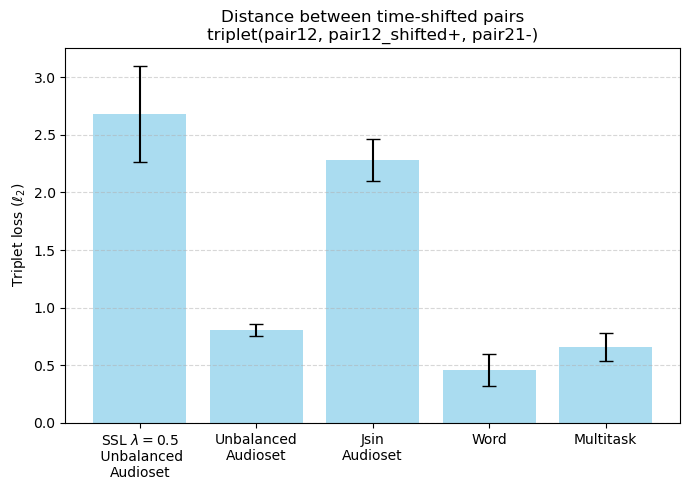

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Helper function to compute mean and standard error from loss tensor
def get_mean_and_std(loss_tensor):
    """
    Compute mean and standard error of the mean from a loss tensor.
    
    Args:
        loss_tensor: Tensor of per-sample losses
    
    Returns:
        mean: Mean loss value
        std_error: Standard error of the mean
    """
    if isinstance(loss_tensor, torch.Tensor):
        loss_tensor = loss_tensor.cpu()
        mean = loss_tensor.mean().item()
        std_error = loss_tensor.std().item() / np.sqrt(len(loss_tensor))
        return mean, std_error
    else:
        return float(loss_tensor), 0.0

model_names = [
    "SSL $\\lambda=0.5$\n Unbalanced\nAudioset",
    "Unbalanced\nAudioset",
    "Jsin\nAudioset",
    "Word",
    "Multitask"
]

# Compute means and standard errors for each model
loss_means = []
loss_errors = []

for loss in [ssl_loss, unbalanced_audioset_losses, jsin_audioset_losses, word_losses, multitask_losses]:
    mean, std_error = get_mean_and_std(loss)
    loss_means.append(mean)
    loss_errors.append(std_error)

plt.figure(figsize=(7,5))
plt.bar(model_names, loss_means, color='skyblue', yerr=loss_errors, capsize=5, alpha=0.7)
plt.ylabel("Triplet loss ($\\ell_2$)")
plt.title("Distance between time-shifted pairs\ntriplet(pair12, pair12_shifted+, pair21-)")
# plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()